<a href="https://colab.research.google.com/github/rahmatnug/capstone-cangkringan-ml/blob/main/eda_musim_tanam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Memuat dataset bersih...


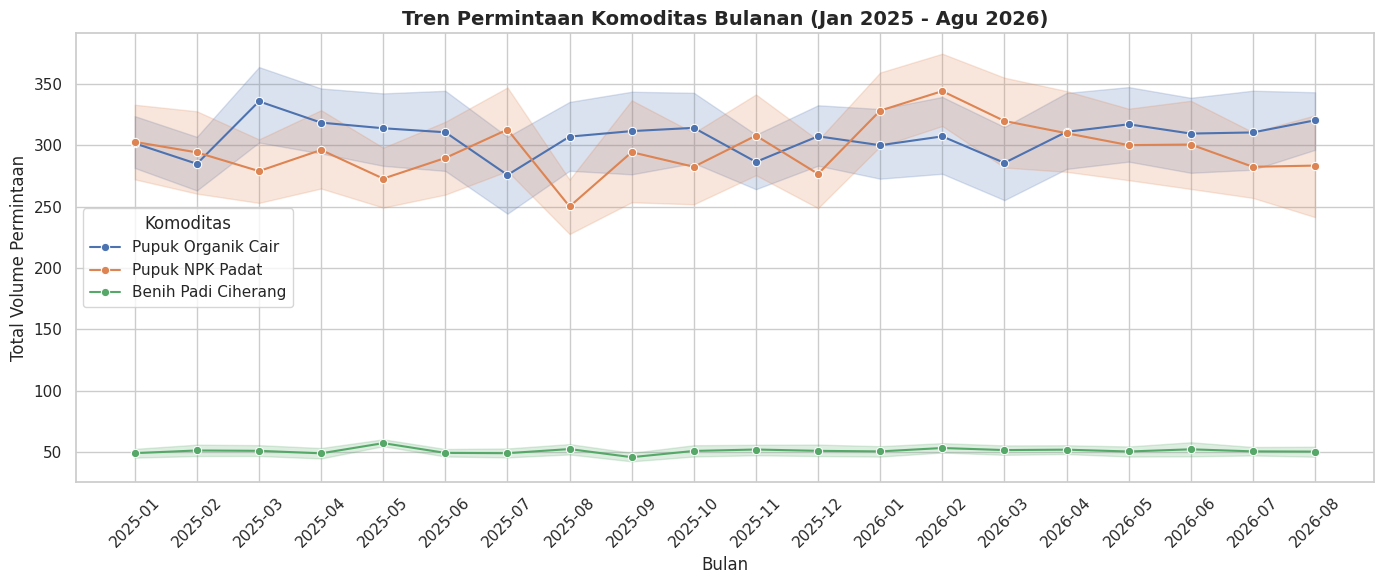

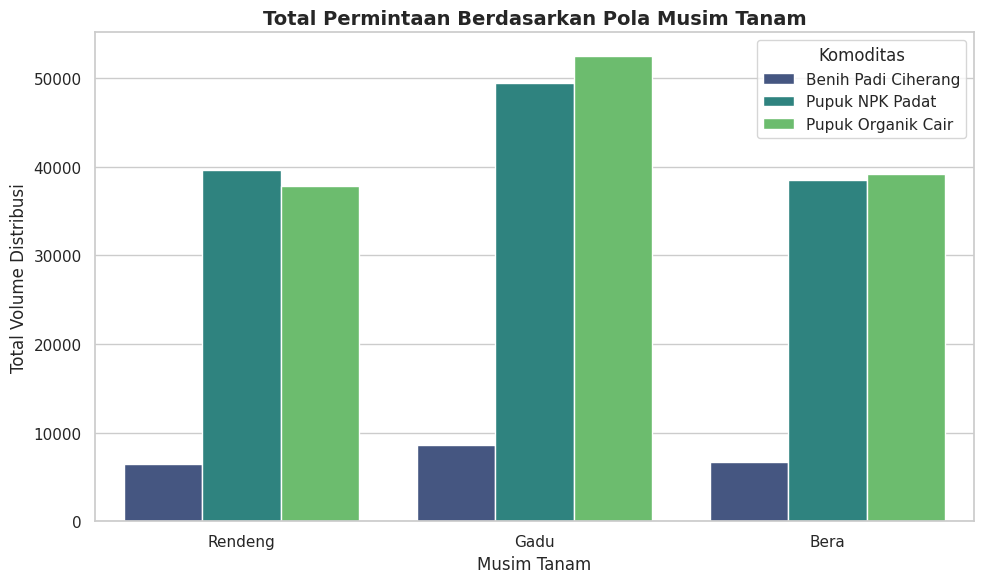


✅ Proses EDA Selesai!
Dua file grafik (grafik_tren_bulanan.png & grafik_musim_tanam.png) berhasil dibuat.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA BERSIH
# ==========================================
print("Memuat dataset bersih...")
df_bersih = pd.read_csv('cleaned_permintaan.csv')
df_komoditas = pd.read_csv('mock_komoditas.csv')

# Gabungkan dengan nama komoditas agar label di grafik lebih mudah dibaca
df_eda = pd.merge(df_bersih, df_komoditas[['id_komoditas', 'nama_komoditas']], on='id_komoditas', how='left')

# Konversi tipe tanggal
df_eda['tanggal_permintaan'] = pd.to_datetime(df_eda['tanggal_permintaan'])
df_eda['Bulan_Angka'] = df_eda['tanggal_permintaan'].dt.month
df_eda['Tahun_Bulan'] = df_eda['tanggal_permintaan'].dt.to_period('M').astype(str)

# ==========================================
# 2. FEATURE ENGINEERING: MUSIM TANAM (Sesuai SRS 1.3)
# ==========================================
def tentukan_musim_tanam(bulan):
    """
    Siklus periodisasi pertanian berdasarkan SRS:
    - Rendeng (Penghujan): November - Februari
    - Gadu (Kemarau): Maret - Juni
    - Bera (Istirahat): Juli - Oktober
    """
    if bulan in [11, 12, 1, 2]:
        return 'Rendeng'
    elif bulan in [3, 4, 5, 6]:
        return 'Gadu'
    else:
        return 'Bera'

df_eda['Musim_Tanam'] = df_eda['Bulan_Angka'].apply(tentukan_musim_tanam)

# ==========================================
# 3. VISUALISASI EDA (Sesuai FR-03)
# ==========================================
sns.set_theme(style="whitegrid")

# Visualisasi 1: Tren Permintaan Historis Bulanan (Time-Series)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_eda, x='Tahun_Bulan', y='volume_permintaan', hue='nama_komoditas', marker='o')
plt.title('Tren Permintaan Komoditas Bulanan (Jan 2025 - Agu 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Volume Permintaan', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Komoditas')
plt.tight_layout()
plt.savefig('grafik_tren_bulanan.png') # Simpan grafik jadi gambar
plt.show()

# Visualisasi 2: Analisis Pola Musim Tanam
plt.figure(figsize=(10, 6))
# Agregasi data per musim tanam dan komoditas
df_musim = df_eda.groupby(['Musim_Tanam', 'nama_komoditas'])['volume_permintaan'].sum().reset_index()

sns.barplot(data=df_musim, x='Musim_Tanam', y='volume_permintaan', hue='nama_komoditas',
            order=['Rendeng', 'Gadu', 'Bera'], palette='viridis')
plt.title('Total Permintaan Berdasarkan Pola Musim Tanam', fontsize=14, fontweight='bold')
plt.xlabel('Musim Tanam', fontsize=12)
plt.ylabel('Total Volume Distribusi', fontsize=12)
plt.legend(title='Komoditas')
plt.tight_layout()
plt.savefig('grafik_musim_tanam.png') # Simpan grafik jadi gambar
plt.show()

print("\n✅ Proses EDA Selesai!")
print("Dua file grafik (grafik_tren_bulanan.png & grafik_musim_tanam.png) berhasil dibuat.")